In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

In [6]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/final_data"
unseen_path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Autoencoder/unseen_data/unseen_data.csv"

euler_nr = pd.read_csv(os.path.join(path, "euler_nr_data.csv"))
datatable = pd.read_csv(os.path.join(path, "Final_data.csv"))

euler_nr = euler_nr[['SubjectID', 'avg_euler_centered_neg_sqrt']].copy()
df = datatable.merge(euler_nr, how="right")
df = df.iloc[:, 2:]

#create dataframe without the last few columns
df_for_blr = df.iloc[:,0:112]
df_unseen = df_for_blr[:3000]
# df_unseen.to_csv(unseen_path)
df_for_blr = df_for_blr[3000:]

#these cols had only zeros (left-vessel had 0s in some cases but not all --> may fit a separate model for this)
df_for_blr = df_for_blr.drop(columns=['SubjectID','5th-Ventricle','Left-WM-hypointensities','Left-non-WM-hypointensities','Left-vessel','Left-WM-hypointensities','Left-non-WM-hypointensities','Right-WM-hypointensities','Right-non-WM-hypointensities'])
df_for_blr 

train_df, test_df = train_test_split(df_for_blr, test_size=0.2, random_state=1107)

scaler = RobustScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

train_tensor = torch.tensor(train_scaled, dtype=torch.float32)
test_tensor = torch.tensor(test_scaled, dtype=torch.float32)

training_data = TensorDataset(train_tensor)
test_data = TensorDataset(test_tensor)

train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [20]:
class AE(nn.Module):
    def __init__(self, input_size=108, latent_size=10):
        super(AE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        self.feature_weights = nn.Parameter(torch.ones(input_size))

        # encoder 
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )

        # decoder 
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def encode(self, x):
        # scale input features by learnable weights
        x = x * self.feature_weights
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)



In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_reconstruction(model, dataloader, device):
    model.eval()
    all_outputs = []
    all_inputs = []

    with torch.no_grad():
        for batch in dataloader:
            x, = batch
            x = x.to(device)
            output = model(x)
            all_outputs.append(output.cpu().numpy())
            all_inputs.append(x.cpu().numpy())

    all_outputs = np.concatenate(all_outputs, axis=0)
    all_inputs = np.concatenate(all_inputs, axis=0)

    mse = mean_squared_error(all_inputs, all_outputs)
    mae = mean_absolute_error(all_inputs, all_outputs)
    r2 = r2_score(all_inputs, all_outputs)

    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    return mse, mae, r2

def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.show()


In [9]:
#ReduceLROnPlateau implementation
def train_ae(model, train_loader, test_loader, epochs, lr):
    loss_func = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.1, patience = 5)
    train_losses = []
    test_losses = []
    

    for epoch in range(epochs):
        
        ################
        #### TRAIN #####
        ################
        
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            x = batch[0]
            prediction = model(x)
            loss = loss_func(prediction, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss_average = train_loss / len(train_loader)
        train_losses.append(train_loss_average)

        
        ################
        ####  TEST #####
        ################
        
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, in test_loader:
                prediction = model(x)
                loss = loss_func(prediction, x)
                test_loss += loss.item()
        test_loss_average = test_loss / len(test_loader)
        test_losses.append(test_loss_average)

        scheduler.step(test_loss_average)
        print(f'Epoch: {epoch+1}')
        print(f'Train loss: {train_loss_average}')
        print(f'Test loss: {test_loss_average}')
        print('\n')

    return train_losses, test_losses
                

Epoch: 1
Train loss: 0.5629348707292716
Test loss: 0.36001748746881884


Epoch: 2
Train loss: 0.33757521017059605
Test loss: 0.31367859710007906


Epoch: 3
Train loss: 0.31433867230153206
Test loss: 0.30558278039097786


Epoch: 4
Train loss: 0.3037457780532188
Test loss: 0.29567186410228413


Epoch: 5
Train loss: 0.2933096402758703
Test loss: 0.2793652930607398


Epoch: 6
Train loss: 0.2785454481762117
Test loss: 0.27126255724579096


Epoch: 7
Train loss: 0.2714182933821728
Test loss: 0.2662548148073256


Epoch: 8
Train loss: 0.26400680449932656
Test loss: 0.2555944157453875


Epoch: 9
Train loss: 0.2552326733139173
Test loss: 0.2502304062557717


Epoch: 10
Train loss: 0.2519443951820204
Test loss: 0.24648313565800586


Epoch: 11
Train loss: 0.24980833120058968
Test loss: 0.24512707302346826


Epoch: 12
Train loss: 0.24819198902208767
Test loss: 0.24413819098845124


Epoch: 13
Train loss: 0.2476292376586904
Test loss: 0.2437294963747263


Epoch: 14
Train loss: 0.2467279335123082
Test l

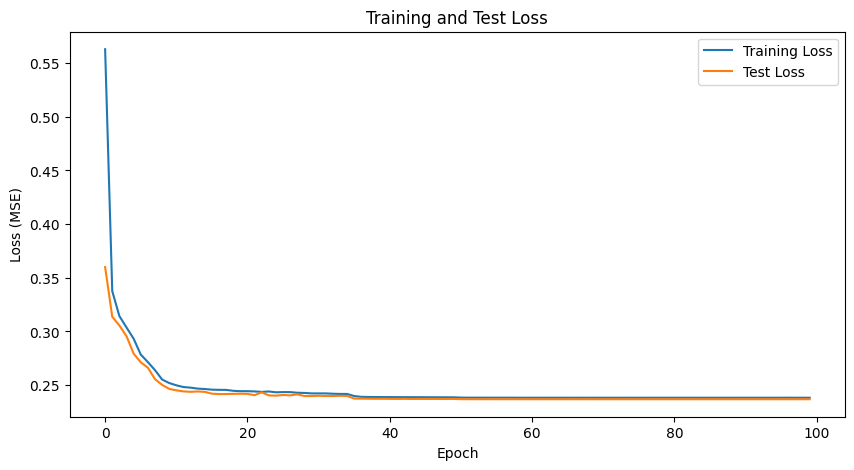

MSE: 0.2369
MAE: 0.3731
R² Score: 0.6201


In [10]:
#autoencoder with only learnable weights
lr = 0.001
epochs = 100
input_size = df_for_blr.shape[1]
model = AE(input_size=input_size, latent_size=10)

train_losses, test_losses = train_ae(model, train_loader, test_loader, epochs=epochs, lr=lr)
plot_losses(train_losses, test_losses)
mse, mae, r2 = evaluate_reconstruction(model, test_loader, device)


In [21]:
def train_ae(model, train_loader, test_loader, epochs, lr, lambda_reg=0.1):
    loss_func = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            optimizer.zero_grad()
            x = batch[0]
            prediction = model(x)

            # Reconstruction loss
            recon_loss = loss_func(prediction, x)

            # Regularization loss: penalize deviation of feature weights from 1
            reg_loss = lambda_reg * torch.sum((model.feature_weights - 1.0) ** 2)

            # Total loss
            loss = recon_loss + reg_loss
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss_average = train_loss / len(train_loader)
        train_losses.append(train_loss_average)

        # Test loop (unchanged)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, in test_loader:
                prediction = model(x)
                loss = loss_func(prediction, x)
                test_loss += loss.item()
        test_loss_average = test_loss / len(test_loader)
        test_losses.append(test_loss_average)

        scheduler.step(test_loss_average)
        print(f'Epoch: {epoch+1}')
        print(f'Train loss: {train_loss_average}')
        print(f'Test loss: {test_loss_average}')
        print('\n')

    return train_losses, test_losses


Epoch: 1
Train loss: 0.5649775433602757
Test loss: 0.3665079791098833


Epoch: 2
Train loss: 0.3576650608584519
Test loss: 0.3262970590343078


Epoch: 3
Train loss: 0.31715422541059124
Test loss: 0.29556772361199063


Epoch: 4
Train loss: 0.2947240713691212
Test loss: 0.2831127035121123


Epoch: 5
Train loss: 0.2818715361322408
Test loss: 0.27321889623999596


Epoch: 6
Train loss: 0.27328098518530114
Test loss: 0.2647950031484167


Epoch: 7
Train loss: 0.26593659880585696
Test loss: 0.25912700640037656


Epoch: 8
Train loss: 0.2596570162482911
Test loss: 0.2521955181534092


Epoch: 9
Train loss: 0.2546543263640079
Test loss: 0.2495946567505598


Epoch: 10
Train loss: 0.25242307801677294
Test loss: 0.24821276776492596


Epoch: 11
Train loss: 0.2505715199946109
Test loss: 0.24615735498567423


Epoch: 12
Train loss: 0.24926301364967335
Test loss: 0.2456953547274073


Epoch: 13
Train loss: 0.24854641696389432
Test loss: 0.24584744699920216


Epoch: 14
Train loss: 0.24823908258170982
Test l

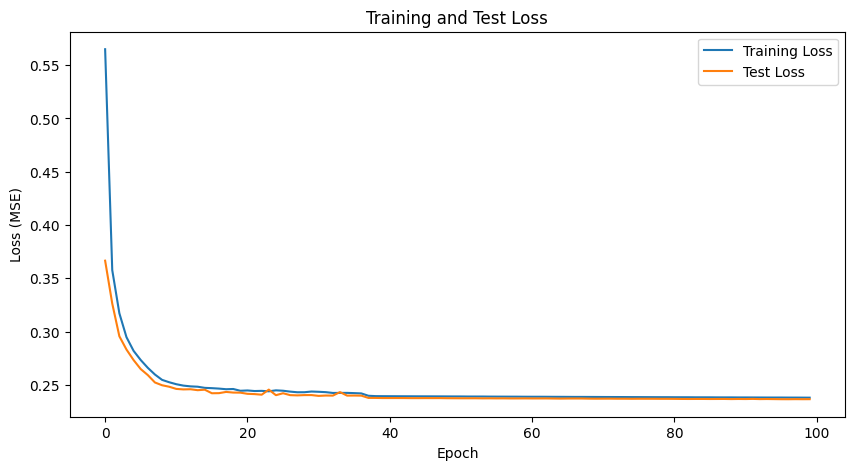

MSE: 0.2366
MAE: 0.3728
R² Score: 0.6208


In [22]:
lr = 0.001
epochs = 100
input_size = df_for_blr.shape[1]
model = AE(input_size=input_size, latent_size=10)

train_losses, test_losses = train_ae(model, train_loader, test_loader, epochs=epochs, lr=lr)
plot_losses(train_losses, test_losses)
mse, mae, r2 = evaluate_reconstruction(model, test_loader, device)


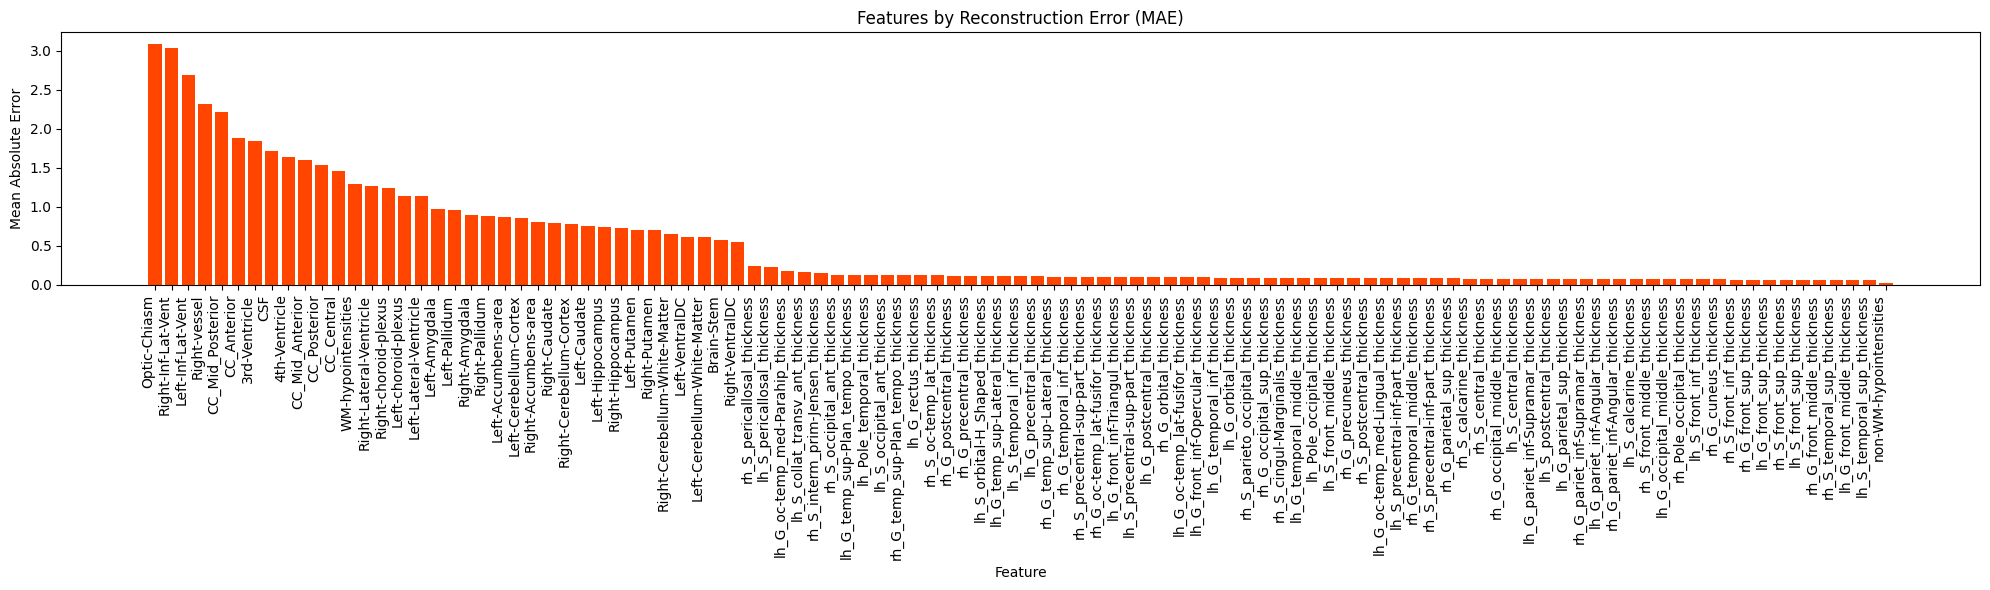

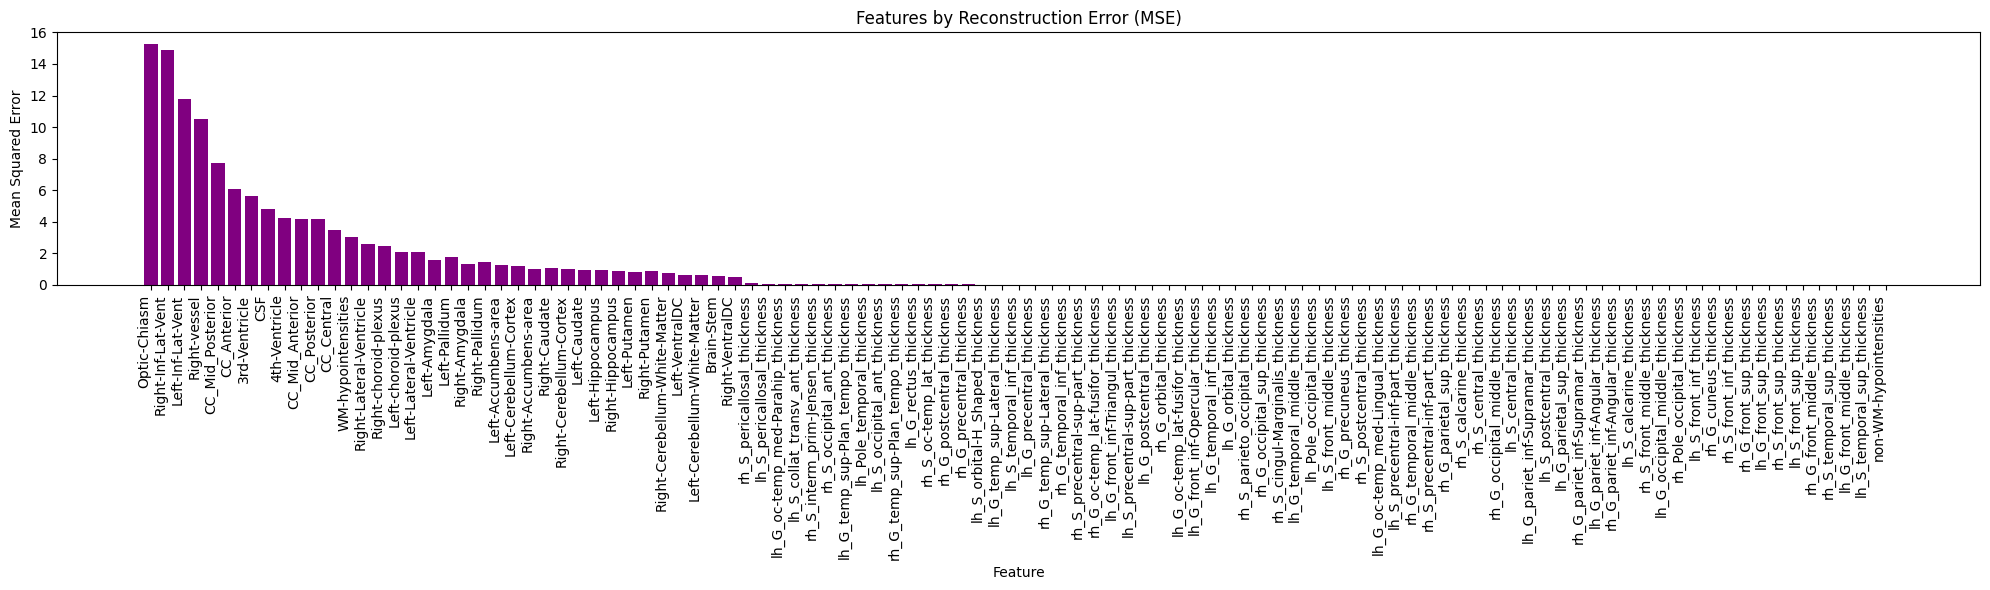

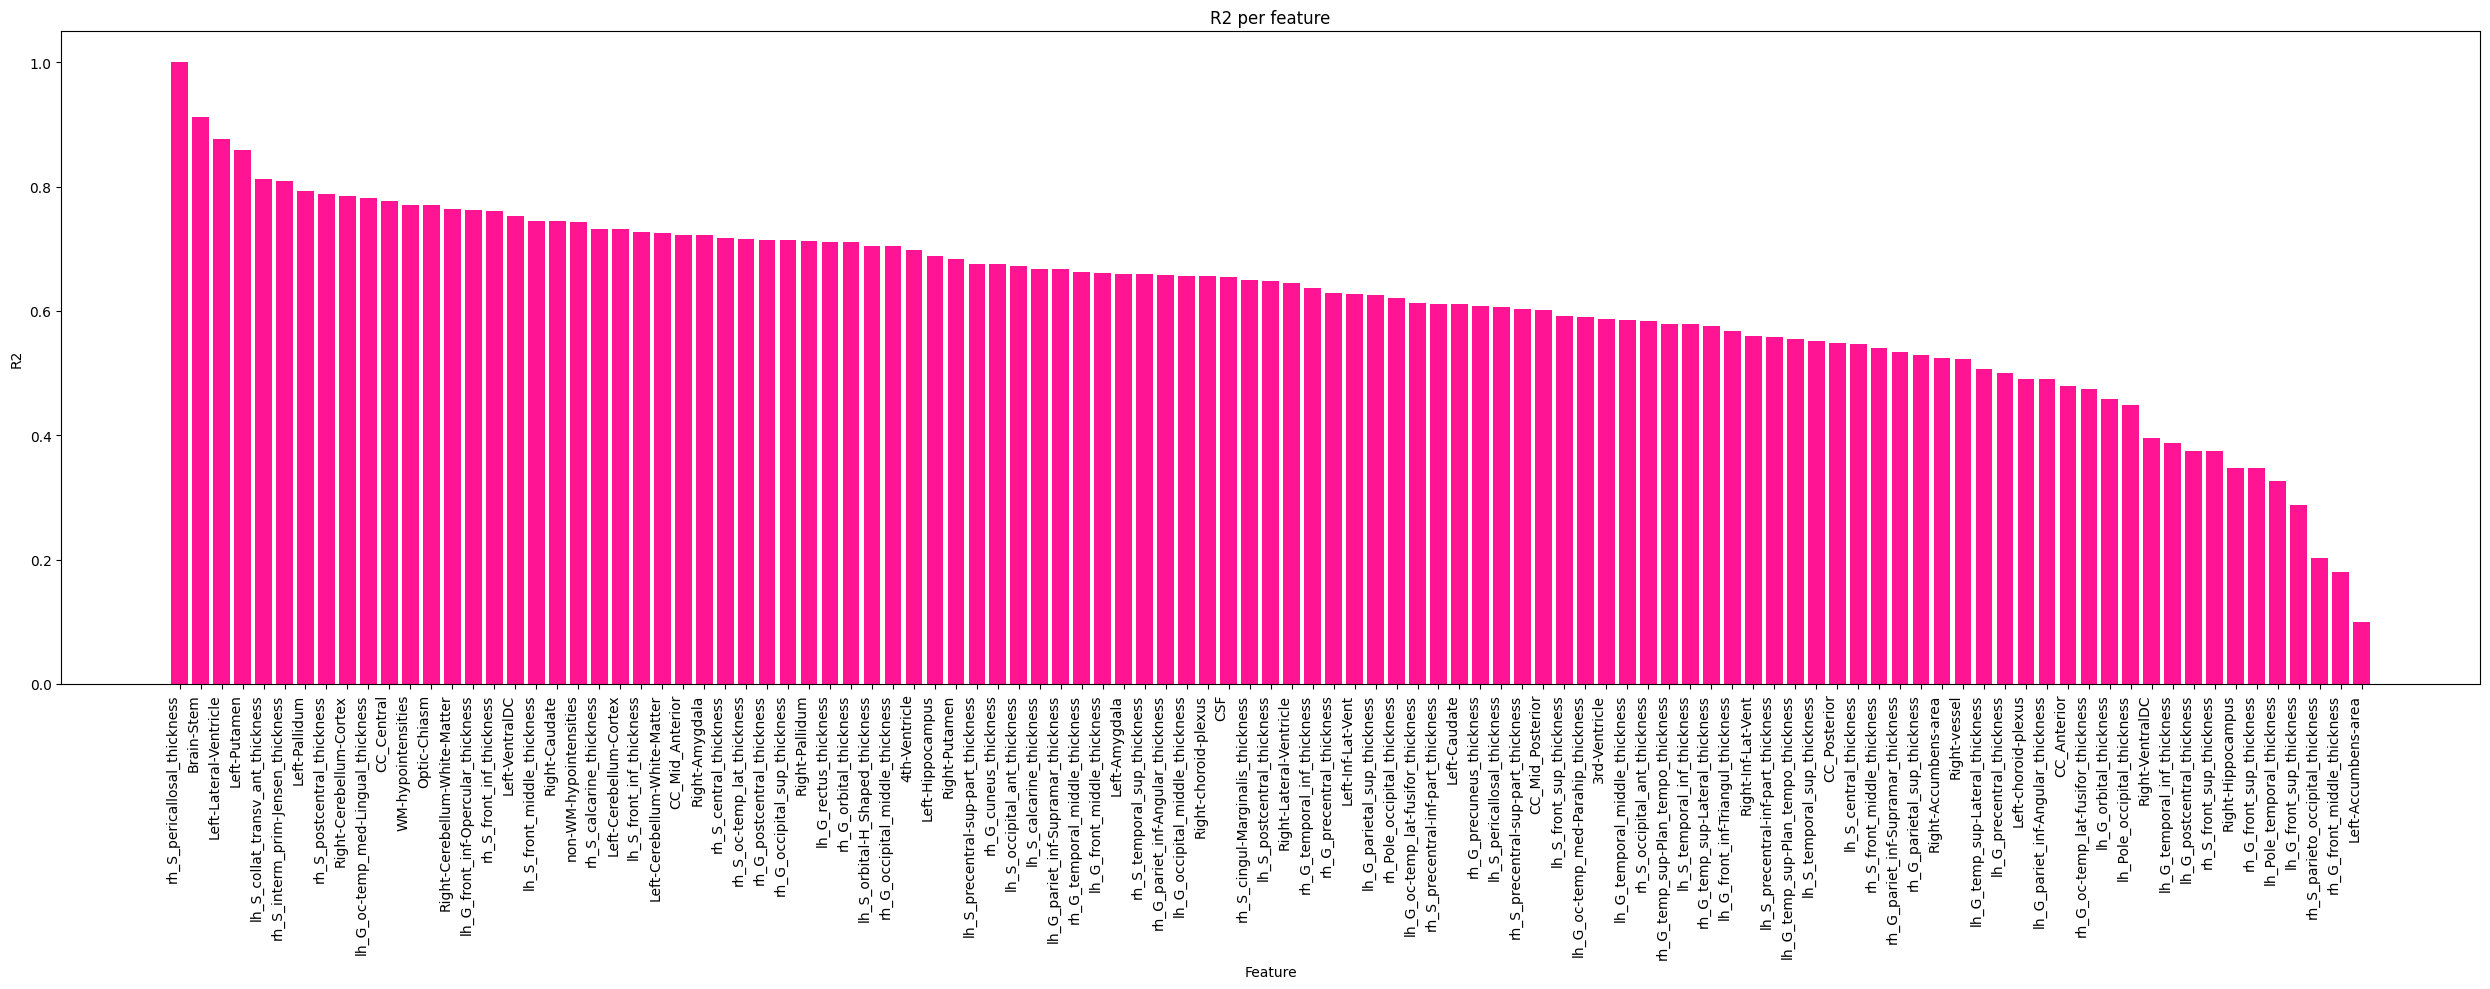

In [24]:
from sklearn.metrics import r2_score
def collect_all_data(model, dataloader):
    model.eval()
    all_inputs = []
    all_outputs = []

    with torch.no_grad():
        for batch, in dataloader:
            x = batch
            output = model(x)

            all_inputs.append(x.cpu().numpy())
            all_outputs.append(output.cpu().numpy())

    all_inputs = np.concatenate(all_inputs, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=0)

    return all_inputs, all_outputs


def plot_feature_errors(feature_error_df):
    
    #MAE
    plt.figure(figsize=(20, 6))
    plt.bar(feature_error_df["feature"], feature_error_df["MAE"],color="orangered")
    plt.xticks(rotation=90, ha="right")
    plt.xlabel("Feature")
    plt.ylabel("Mean Absolute Error")
    plt.title(f"Features by Reconstruction Error (MAE)")
    plt.tight_layout()
    plt.show()

    #MSE
    plt.figure(figsize=(20, 6))
    plt.bar(feature_error_df["feature"], feature_error_df["MSE"], color="purple")
    plt.xticks(rotation=90, ha="right")
    plt.xlabel("Feature")
    plt.ylabel("Mean Squared Error")
    plt.title(f"Features by Reconstruction Error (MSE)")
    plt.tight_layout()
    plt.show()

    feature_error_df = feature_error_df.sort_values("R2", ascending=False)
    
    #R2
    plt.figure(figsize=(25, 10))
    plt.bar(feature_error_df["feature"], feature_error_df["R2"], color="deeppink")
    plt.xticks(rotation=90, ha="right")
    plt.xlabel("Feature")
    plt.ylabel("R2")
    plt.title("R2 per feature")
    plt.tight_layout()
    plt.show()

def plot_features(inputs_original, outputs_original, feature_names, feature_name, bins=50):

    idx = feature_names.index(feature_name)

    actual = inputs_original[:, idx]
    predicted = outputs_original[:, idx]
    error = predicted - actual
    
    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    r2 = r2_score(actual, predicted)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # actual vs prediction
    axes[0].hist(actual, bins=bins, alpha=0.6, label="Actual", color="gold")
    axes[0].hist(predicted, bins=bins, alpha=0.6, label="Prediction", color="purple")
    axes[0].set_xlabel(feature_name)
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"{feature_name}: Actual vs Reconstruction\nR² = {r2:.3f}")
    axes[0].legend()

    # mae & mse
    axes[1].hist(error, bins=bins, color="coral")
    axes[1].set_xlabel("Reconstruction Error")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Error Distribution\nMAE = {mae:.4f} | MSE = {mse:.4f}")

    plt.tight_layout()
    plt.show()


feature_names = df_for_blr.columns.to_list()
num_features = len(feature_names)

inputs_scaled, outputs_scaled = collect_all_data(model, test_loader)

inputs_orig = scaler.inverse_transform(inputs_scaled)
outputs_orig = scaler.inverse_transform(outputs_scaled)

errors = outputs_orig - inputs_orig
abs_errors = np.abs(errors)

feature_error_df = pd.DataFrame({
    "feature": feature_names,
    "MAE": abs_errors.mean(axis=0),
    "MSE": (errors ** 2).mean(axis=0)
}).sort_values("MAE", ascending=False)


r2_scores = [
    r2_score(inputs_orig[:, i], outputs_orig[:, i])
    for i in range(len(feature_names))
]

feature_error_df["R2"] = r2_scores

plot_feature_errors(feature_error_df)


In [25]:
#autoencoder with attention
class AttentionAE(nn.Module):
    def __init__(self, input_size=108, latent_size=10):
        super(AttentionAE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        # attention layer
        self.attention = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Softmax(dim=1)
        )

        # encoder 
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )

        # decoder 
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def forward(self, x):
        # apply attention to input features
        attention_weights = self.attention(x)
        x_attended = x * attention_weights
        z = self.encoder(x_attended)
        return self.decoder(z)



#ReduceLROnPlateau implementation
def train_ae(model, train_loader, test_loader, epochs, lr):
    loss_func = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.1, patience = 5)
    train_losses = []
    test_losses = []
    

    for epoch in range(epochs):
        
        ################
        #### TRAIN #####
        ################
        
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            optimizer.zero_grad()
            x = batch[0]
            prediction = model(x)
            loss = loss_func(prediction, x)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss_average = train_loss / len(train_loader)
        train_losses.append(train_loss_average)

        
        ################
        ####  TEST #####
        ################
        
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for x, in test_loader:
                prediction = model(x)
                loss = loss_func(prediction, x)
                test_loss += loss.item()
        test_loss_average = test_loss / len(test_loader)
        test_losses.append(test_loss_average)

        scheduler.step(test_loss_average)
        print(f'Epoch: {epoch+1}')
        print(f'Train loss: {train_loss_average}')
        print(f'Test loss: {test_loss_average}')
        print('\n')

    return train_losses, test_losses
                

Epoch: 1
Train loss: 0.565444268403253
Test loss: 0.3468806203454733


Epoch: 2
Train loss: 0.3381346910411775
Test loss: 0.31957569159567356


Epoch: 3
Train loss: 0.3146127883676459
Test loss: 0.30006817759325105


Epoch: 4
Train loss: 0.29721460253468357
Test loss: 0.2881893152371049


Epoch: 5
Train loss: 0.2892971336841583
Test loss: 0.27672345998386544


Epoch: 6
Train loss: 0.2794043263371702
Test loss: 0.27245174068957567


Epoch: 7
Train loss: 0.2780051921830752
Test loss: 0.2707137274555862


Epoch: 8
Train loss: 0.27463788675700185
Test loss: 0.2663566024663548


Epoch: 9
Train loss: 0.2656414663682433
Test loss: 0.25628910524149734


Epoch: 10
Train loss: 0.2593956514022737
Test loss: 0.25299640915667015


Epoch: 11
Train loss: 0.257014716990019
Test loss: 0.2517942727232973


Epoch: 12
Train loss: 0.25468682337805865
Test loss: 0.2496341768031319


Epoch: 13
Train loss: 0.25354259433858684
Test loss: 0.2498327724946042


Epoch: 14
Train loss: 0.252957979265932
Test loss: 0

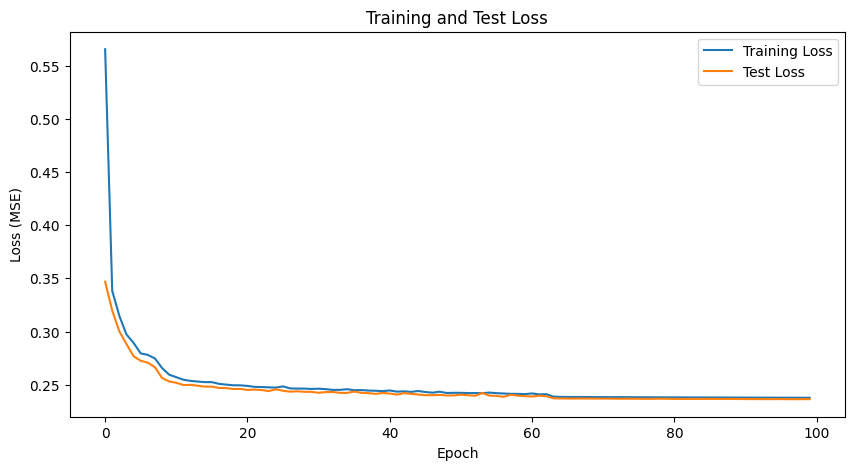

MSE: 0.2365
MAE: 0.3730
R² Score: 0.6202


In [26]:
lr = 0.001
epochs = 100
input_size = df_for_blr.shape[1]
model = AE(input_size=input_size, latent_size=10)

train_losses, test_losses = train_ae(model, train_loader, test_loader, epochs=epochs, lr=lr)
plot_losses(train_losses, test_losses)
mse, mae, r2 = evaluate_reconstruction(model, test_loader, device)
